# Phase 3 — The rigid-body ("6-DOF") F-16

The point-mass model of notebook 2 lets the pilot *command* an angle of attack. A real aircraft
does not work like that: the pilot moves **control surfaces**, which create **moments**, which
rotate the aircraft, which changes the angle of attack, which changes the forces. This notebook
builds that full chain — six degrees of freedom (3 translations + 3 rotations).

This is the "real" aircraft of the project: the final RL goal is an agent that flies it by
moving its control surfaces directly.

Code: `src/jetfighter/aircraft/dynamics_6dof.py`, `f16_aero.py`, `analysis.py`; tables in
`configs/aircraft/f16_sl_tables.yaml`.

In [1]:
%matplotlib inline
import math
import time

import matplotlib.pyplot as plt
import numpy as np

from jetfighter.aircraft import analysis as an
from jetfighter.aircraft import dynamics_6dof as d6
from jetfighter.aircraft.params import load_aircraft
from jetfighter.core.frames import body_to_ned
from jetfighter.core.integrators import simulate
from jetfighter.viz.style import GRID, INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
DEG = math.pi / 180

params = load_aircraft("f16")
model = d6.F16SixDof(params)  # default center of gravity x_cg = 0.30 (stable)

## 1. Equations of motion

Newton's and Euler's laws, written in the **body frame** (where the inertia tensor is
constant), plus the quaternion kinematics and the navigation equation:

$$m\,(\dot{\mathbf v} + \boldsymbol\omega \times \mathbf v) = \mathbf F_{aero} + \mathbf F_{thrust} + m\,\mathbf g_b$$
$$I\,\dot{\boldsymbol\omega} + \boldsymbol\omega \times (I\boldsymbol\omega + \mathbf h_{eng}) = \mathbf M_{aero}$$
$$\dot q = \tfrac12\, q \otimes [0, \boldsymbol\omega], \qquad \dot{\mathbf p}_{ned} = C_{nb}(q)\,\mathbf v$$

* $\mathbf v = [u, v, w]$ is the velocity in body axes, $\boldsymbol\omega = [p, q, r]$ the roll,
  pitch and yaw rates;
* the $\boldsymbol\omega \times \dots$ terms appear because the body frame rotates;
* $I$ includes the cross product of inertia $I_{xz}$ (the F-16 is symmetric left/right only);
* $\mathbf h_{eng}$ is the angular momentum of the spinning engine (a gyroscopic effect).

**State (17):** position (3), body velocity (3), quaternion (4), angular rates (3), engine
power (1), actual surface deflections (3). **Controls (4):** throttle, elevator $\delta_e$,
ailerons $\delta_a$, rudder $\delta_r$.

In [2]:
inertia = params.mass.inertia_tensor
print("inertia tensor [kg·m²]:\n", np.round(inertia, 0))
print(f"\nengine angular momentum: {model.h_engine[0]:.0f} kg·m²/s along the body x axis")

inertia tensor [kg·m²]:
 [[12875.     0. -1331.]
 [    0. 75674.     0.]
 [-1331.     0. 85552.]]

engine angular momentum: 217 kg·m²/s along the body x axis


Note $I_{yy}, I_{zz} \gg I_{xx}$: a fighter is long and has short wings, so it rolls easily
(small $I_{xx}$) but pitches and yaws reluctantly.

### Validation: a torque-free body conserves its angular momentum

With aerodynamics, thrust and gravity switched off, the rotational kinetic energy and the
angular momentum in the *inertial* frame must be constant — a sharp test of the Euler
equations, the $I_{xz}$ term and the engine gyroscopic term (`tests/test_dynamics_6dof.py`).

In [3]:
free = d6.F16SixDof(params, gravity=0.0)
zero = type("Zero", (), {"CX": 0.0, "CY": 0.0, "CZ": 0.0, "Cl": 0.0, "Cm": 0.0, "Cn": 0.0})
free.aero.coefficients = lambda *args, **kwargs: zero  # no aerodynamics
free.engine.thrust = lambda *args, **kwargs: 0.0  # no thrust
x0 = free.make_state(altitude=5000, airspeed=200, rates=(1.2, -0.7, 0.4), power=0.0)
res = simulate(free.derivatives, x0, 30.0, dt=0.005, u_const=np.zeros(4), post_step=free.post_step)


def invariants(x):
    w = x[d6.RATES]
    energy = 0.5 * w @ free.inertia @ w
    momentum_ned = body_to_ned(x[d6.QUAT], free.inertia @ w + free.h_engine)
    return energy, momentum_ned


e0, h0 = invariants(res.x[0])
de = max(abs(invariants(x)[0] - e0) / e0 for x in res.x[::100])
dh = max(np.linalg.norm(invariants(x)[1] - h0) / np.linalg.norm(h0) for x in res.x[::100])
print(f"30 s of free tumbling: max relative drift, energy {de:.1e}, angular momentum {dh:.1e}")

30 s of free tumbling: max relative drift, energy 1.5e-12, angular momentum 3.8e-11


## 2. Aerodynamics from NASA wind-tunnel data

The F-16 was chosen precisely because its aerodynamic data is public (Nguyen et al., NASA
TP-1538, 1979, as tabulated in Stevens & Lewis, *Aircraft Control and Simulation*). The
coefficients are **lookup tables** in angle of attack $\alpha$, sideslip $\beta$ and surface
deflections, plus **damping derivatives** proportional to the angular rates. For example, the
pitching moment:

$$C_m = C_m(\alpha, \delta_e) + \frac{\bar c\, q}{2V}\, C_{m_q}(\alpha) + C_Z\,(x_{cg,ref} - x_{cg})$$

The damping term $C_{m_q}$ opposes rotation — without it the aircraft would oscillate forever.
The last term moves the moment from the reference center of gravity to the actual one (more on
that in section 3). Forces and moments then follow as
$F = \bar q S C_{X,Y,Z}$, $M = \bar q S \{b C_l,\ \bar c C_m,\ b C_n\}$.

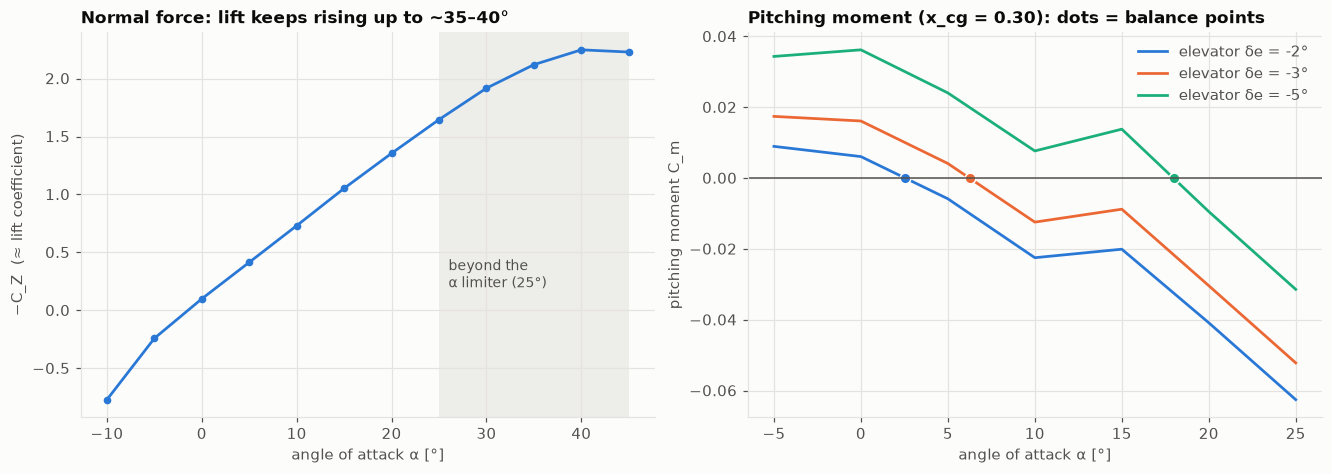

In [4]:
t = model.aero.t  # the raw tables
alphas = t.alpha.values
elevators = t.elevator.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), layout="constrained")
axes[0].plot(alphas, -t.cz_alpha, color=SERIES[0], marker="o", markersize=4)
axes[0].axvspan(25, 45, color=GRID, alpha=0.6, linewidth=0)
axes[0].text(26, 0.2, "beyond the\nα limiter (25°)", color=INK_2, fontsize=9)
axes[0].set_xlabel("angle of attack α [°]"), axes[0].set_ylabel("−C_Z  (≈ lift coefficient)")
axes[0].set_title("Normal force: lift keeps rising up to ~35–40°")

alpha_fine = np.linspace(-5, 25, 121)
for de, color in zip((-2, -3, -5), SERIES, strict=True):
    cm = np.array(
        [
            model.aero.coefficients(a * DEG, 0, de * DEG, 0, 0, 0, 0, 0, 200.0, model.xcg).Cm
            for a in alpha_fine
        ]
    )
    axes[1].plot(alpha_fine, cm, color=color, label=f"elevator δe = {de:+d}°")
    k = np.flatnonzero(np.diff(np.sign(cm)))[0]  # first zero crossing
    trim_alpha = np.interp(0.0, cm[[k + 1, k]], alpha_fine[[k + 1, k]])
    axes[1].plot(trim_alpha, 0, "o", color=color, markersize=7, markeredgecolor="white")
axes[1].axhline(0, color=INK_2, linewidth=1)
axes[1].set_xlabel("angle of attack α [°]"), axes[1].set_ylabel("pitching moment C_m")
axes[1].set_title("Pitching moment (x_cg = 0.30): dots = balance points")
axes[1].legend(loc="upper right")
plt.show()

Where a $C_m$ curve crosses zero (dots), the aircraft is balanced in pitch: that is its **trim angle of
attack** for this elevator setting. Pulling the stick (more negative $\delta_e$, trailing edge up)
raises the curve and moves the balance point to a higher $\alpha$: a few degrees of elevator
span the whole useful range of angle of attack.

## 3. Static stability and the center of gravity

An aircraft is **statically stable** in pitch if, when a gust raises its nose, the aerodynamic
moment pushes it back down: $\partial C_m / \partial\alpha < 0$. This depends on where the
center of gravity (CG) sits relative to the aerodynamic center: the further aft the CG, the less
stable.

The real F-16 is **deliberately unstable** (relaxed static stability) — it is more agile, and
its fly-by-wire computer keeps it flying. At the nominal CG of the tables ($x_{cg} = 0.35\bar c$)
the model is indeed unstable. The project's decision was to start with a stable CG
($x_{cg} = 0.30\bar c$) and bring back the unstable one once phase 6 provides fly-by-wire.

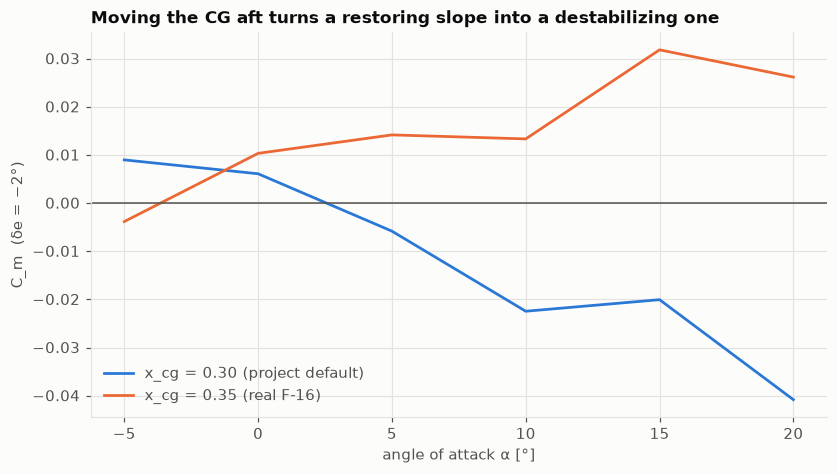

In [5]:
alpha_grid = np.linspace(-5, 20, 101)
fig, ax = plt.subplots(figsize=(7.5, 4.2), layout="constrained")
for xcg, color, label in (
    (0.30, SERIES[0], "x_cg = 0.30 (project default)"),
    (0.35, SERIES[1], "x_cg = 0.35 (real F-16)"),
):
    cm = [
        model.aero.coefficients(a * DEG, 0, -2 * DEG, 0, 0, 0, 0, 0, 200.0, xcg).Cm
        for a in alpha_grid
    ]
    ax.plot(alpha_grid, cm, color=color, label=label)
ax.axhline(0, color=INK_2, linewidth=1)
ax.set_xlabel("angle of attack α [°]"), ax.set_ylabel("C_m  (δe = −2°)")
ax.set_title("Moving the CG aft turns a restoring slope into a destabilizing one")
ax.legend(loc="lower left")
plt.show()

With $x_{cg} = 0.30$ the slope is negative (a stable "spring"); at $0.35$ it is
positive around the typical trim angles — a disturbance grows instead
of dying out. We will *see* this in the time responses below.

## 4. Actuators

Control surfaces are moved by hydraulic servos: first-order lag ($\tau \approx 0.05$ s),
**rate-limited** (60°/s for the elevator) and **position-limited** (±25°). This matters for RL:
it prevents the agent from learning physically impossible "bang-bang" commands.

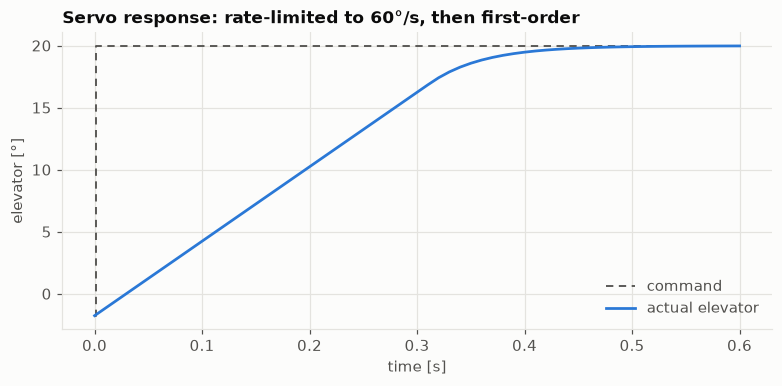

In [6]:
x, u = model.trim(3000, 200)
u_step = u.copy()
u_step[d6.ELEVATOR] = 20 * DEG  # ask for a large, instant deflection
times, deflection = [0.0], [x[d6.DE] / DEG]
for k in range(60):
    x = model.step(x, u_step)
    times.append((k + 1) * 0.01)
    deflection.append(x[d6.DE] / DEG)
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.step(
    [0, 0.001, 0.6],
    [u[d6.ELEVATOR] / DEG, 20, 20],
    where="post",
    color=INK_2,
    linewidth=1.2,
    linestyle=(0, (4, 3)),
    label="command",
)
ax.plot(times, deflection, color=SERIES[0], label="actual elevator")
ax.set_xlabel("time [s]"), ax.set_ylabel("elevator [°]")
ax.set_title("Servo response: rate-limited to 60°/s, then first-order")
ax.legend(loc="lower right")
plt.show()

## 5. Trim with six unknowns

Finding steady level flight is now a 6-unknown problem: $\alpha$, $\beta$, throttle,
$\delta_e$, $\delta_a$, $\delta_r$ such that all accelerations vanish,
$\dot u = \dot v = \dot w = \dot p = \dot q = \dot r = 0$. `trim()` solves it as a bounded
nonlinear least-squares problem (`scipy.optimize.least_squares`). The test suite checks it
reproduces the published Stevens & Lewis trim point (throttle 0.1385, elevator −0.759°).

In [7]:
print(f"{'flight condition':<20}{'throttle':>9}{'elevator':>10}{'α':>8}{'Mach':>7}")
for h, v in [(0, 153), (3000, 200), (6000, 250), (9000, 250)]:
    x, u = model.trim(h, v)
    fd = model.flight_data(x)
    print(
        f"{h:>5} m, {v:>3} m/s     {u[0]:>9.3f}{u[1] / DEG:>9.2f}°{fd.alpha / DEG:>7.2f}°"
        f"{fd.mach:>7.2f}"
    )

flight condition     throttle  elevator       α   Mach
    0 m, 153 m/s         0.149    -1.93°   2.26°   0.45
 3000 m, 200 m/s         0.221    -1.74°   1.48°   0.61
 6000 m, 250 m/s         0.359    -1.66°   1.13°   0.79
 9000 m, 250 m/s         0.342    -1.91°   2.20°   0.82


## 6. Linearization and natural modes

Around a trim point, the nonlinear dynamics behave like a linear system $\dot{\delta s} =
A\,\delta s + B\,\delta u$ on the reduced state $s = [V, \alpha, \beta, \phi, \theta, p, q, r]$.
`analysis.linearize` computes $A$ and $B$ by central finite differences. The **eigenvalues**
of $A$ are the aircraft's natural modes — each classic mode of flight mechanics should appear:

| Mode | Motion | Expected |
|---|---|---|
| Short period | fast pitch/α oscillation | period of a few seconds, well damped |
| Phugoid | slow exchange of speed and altitude | period 30–100 s, lightly damped |
| Dutch roll | coupled yaw/roll wobble | period ~2 s |
| Roll subsidence | roll rate settling | τ ~0.3 s |
| Spiral | slow bank divergence or convergence | very slow |

In [8]:
x, u = model.trim(3000, 200)
A, B = an.linearize(model, x, u)
modes = an.flight_modes(A)
ENGLISH = {
    "short_period": "short period",
    "phugoid": "phugoid",
    "dutch_roll": "Dutch roll",
    "roll": "roll subsidence",
    "spiral": "spiral",
}
print(f"modes at 3000 m, 200 m/s, x_cg = {model.xcg}:")
for key, m in modes.items():
    name = ENGLISH.get(key, key)
    if m.eigenvalue.imag:
        print(
            f"  {name:<18} ω = {m.natural_frequency:5.2f} rad/s   ζ = {m.damping:4.2f}"
            f"   period = {m.period:6.1f} s"
        )
    else:
        print(f"  {name:<18} τ = {m.time_constant:6.2f} s")

modes at 3000 m, 200 m/s, x_cg = 0.3:
  short period       ω =  2.06 rad/s   ζ = 0.56   period =    3.7 s
  phugoid            ω =  0.06 rad/s   ζ = 0.17   period =  107.1 s
  Dutch roll         ω =  3.58 rad/s   ζ = 0.12   period =    1.8 s
  roll subsidence    τ =   0.28 s
  spiral             τ =  97.69 s


All five classic modes are there with textbook magnitudes, and all are stable (the spiral
converges slowly, τ ≈ 100 s). Plotting the longitudinal eigenvalues in the complex plane for both CG positions shows the
instability directly: at $x_{cg} = 0.35$ the short-period pair splits into two real roots, one
of them in the **right half-plane** (positive real part = exponential divergence).

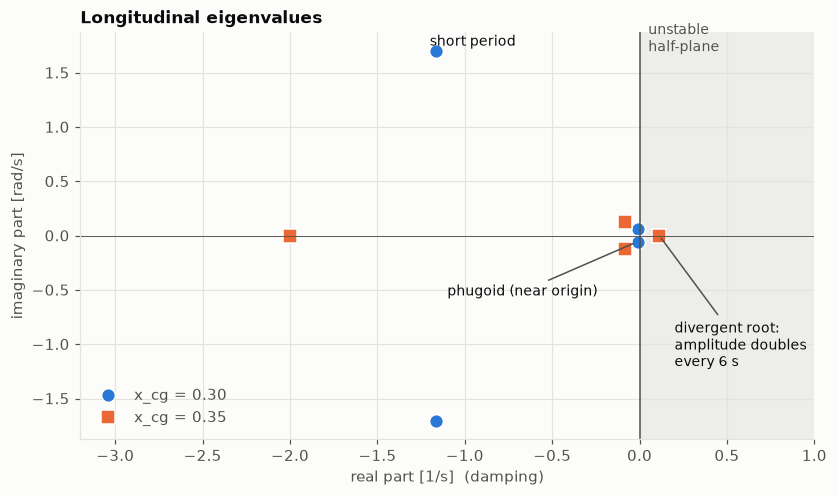

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.4), layout="constrained")
for xcg, color, marker in ((0.30, SERIES[0], "o"), (0.35, SERIES[1], "s")):
    m = d6.F16SixDof(params, xcg=xcg)
    xt, ut = m.trim(3000, 200)
    A_ = an.linearize(m, xt, ut)[0]
    lon = np.linalg.eigvals(A_[np.ix_(an.LONGITUDINAL, an.LONGITUDINAL)])
    ax.plot(
        lon.real,
        lon.imag,
        marker,
        color=color,
        markersize=9,
        markeredgecolor="white",
        label=f"x_cg = {xcg:.2f}",
    )
    lam_max = lon.real.max()
ax.axvspan(0, 1.0, color=GRID, alpha=0.6, linewidth=0)
ax.text(0.05, 1.7, "unstable\nhalf-plane", color=INK_2, fontsize=9)
ax.axvline(0, color=INK_2, linewidth=1)
ax.axhline(0, color=INK_2, linewidth=0.6)
ax.annotate("short period", (-1.2, 1.75), color=INK, fontsize=9)
ax.annotate(
    "phugoid (near origin)",
    (-0.02, -0.06),
    xytext=(-1.1, -0.55),
    color=INK,
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": INK_2},
)
ax.annotate(
    f"divergent root:\namplitude doubles\nevery {math.log(2) / lam_max:.0f} s",
    (lam_max, 0),
    xytext=(0.2, -1.2),
    color=INK,
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": INK_2},
)
ax.set_xlim(-3.2, 1.0)
ax.set_xlabel("real part [1/s]  (damping)"), ax.set_ylabel("imaginary part [rad/s]")
ax.set_title("Longitudinal eigenvalues")
ax.legend(loc="lower left")
plt.show()

## 7. Responses to the controls

The best sanity check of signs and magnitudes: poke each control from trimmed flight and look.

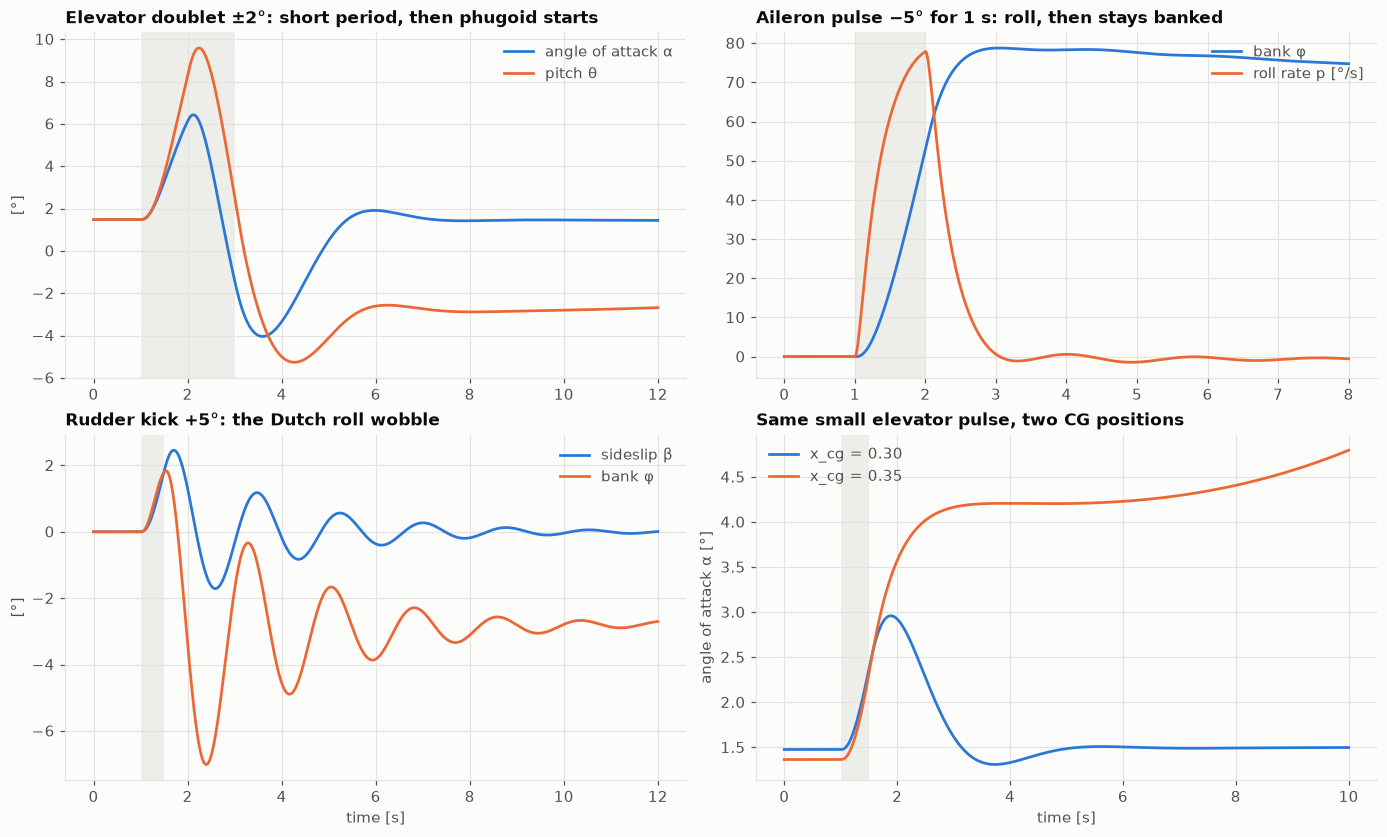

In [10]:
H0, V0 = 3000.0, 200.0


def respond(m, pulse, t_end):
    x0, u0 = m.trim(H0, V0)
    r = simulate(
        m.derivatives, x0, t_end, controller=lambda t, _x: u0 + pulse(t), post_step=m.post_step
    )
    return r.t, [m.flight_data(x) for x in r.x]


def pulse(index, amplitude, t_on, t_off):
    def f(t):
        du = np.zeros(4)
        if t_on <= t < t_off:
            du[index] = amplitude
        return du

    return f


def doublet(index, amplitude, t0, width):
    def f(t):
        du = np.zeros(4)
        if t0 <= t < t0 + width:
            du[index] = amplitude
        elif t0 + width <= t < t0 + 2 * width:
            du[index] = -amplitude
        return du

    return f


fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5), layout="constrained")

ax = axes[0, 0]
tt, data = respond(model, doublet(d6.ELEVATOR, -2 * DEG, 1.0, 1.0), 12.0)
ax.plot(tt, [d.alpha / DEG for d in data], color=SERIES[0], label="angle of attack α")
ax.plot(tt, [d.pitch / DEG for d in data], color=SERIES[1], label="pitch θ")
ax.axvspan(1, 3, color=GRID, alpha=0.6, linewidth=0)
ax.set_title("Elevator doublet ±2°: short period, then phugoid starts")
ax.set_ylabel("[°]"), ax.legend(loc="upper right")

ax = axes[0, 1]
tt, data = respond(model, pulse(d6.AILERON, -5 * DEG, 1.0, 2.0), 8.0)
ax.plot(tt, [d.roll / DEG for d in data], color=SERIES[0], label="bank φ")
ax.plot(tt, [d.p / DEG for d in data], color=SERIES[1], label="roll rate p [°/s]")
ax.axvspan(1, 2, color=GRID, alpha=0.6, linewidth=0)
ax.set_title("Aileron pulse −5° for 1 s: roll, then stays banked")
ax.legend(loc="upper right")

ax = axes[1, 0]
tt, data = respond(model, pulse(d6.RUDDER, 5 * DEG, 1.0, 1.5), 12.0)
ax.plot(tt, [d.beta / DEG for d in data], color=SERIES[0], label="sideslip β")
ax.plot(tt, [d.roll / DEG for d in data], color=SERIES[1], label="bank φ")
ax.axvspan(1, 1.5, color=GRID, alpha=0.6, linewidth=0)
ax.set_title("Rudder kick +5°: the Dutch roll wobble")
ax.set_xlabel("time [s]"), ax.set_ylabel("[°]"), ax.legend(loc="upper right")

ax = axes[1, 1]
for xcg, color in ((0.30, SERIES[0]), (0.35, SERIES[1])):
    tt, data = respond(d6.F16SixDof(params, xcg=xcg), pulse(d6.ELEVATOR, -1 * DEG, 1.0, 1.5), 10.0)
    ax.plot(tt, [d.alpha / DEG for d in data], color=color, label=f"x_cg = {xcg:.2f}")
ax.axvspan(1, 1.5, color=GRID, alpha=0.6, linewidth=0)
ax.set_title("Same small elevator pulse, two CG positions")
ax.set_xlabel("time [s]"), ax.set_ylabel("angle of attack α [°]")
ax.legend(loc="upper left")
plt.show()

* **Elevator:** α and θ respond within a second and settle — the short period is well damped.
* **Ailerons:** the aircraft rolls while the ailerons are deflected, then *stays* banked (no
  natural roll-back): a pilot or autopilot has to level the wings.
* **Rudder:** sideslip and bank oscillate together with a ~2 s period — the Dutch roll, lightly
  damped, which is why real aircraft have a yaw damper (added in notebook 6).
* **CG:** at $x_{cg} = 0.30$ the pulse dies out; at $0.35$ the angle of attack keeps
  **diverging** after the pulse ends. This aircraft cannot be flown by hand — it needs
  fly-by-wire, or a very good RL agent.

## 8. Cost

The 6-DOF model is heavier than the point mass (table lookups, 17 states), but still fast:

In [11]:
x, u = model.trim(H0, V0)
t0 = time.perf_counter()
for _ in range(2000):
    x = model.step(x, u)
rate = 2000 / (time.perf_counter() - t0)
print(f"{rate:,.0f} physics steps/s = {rate * 0.01:,.0f}× real time")

7,191 physics steps/s = 72× real time


## Takeaways

* The 6-DOF model integrates the **full Newton-Euler equations** with the real F-16 wind-tunnel
  tables; it matches the reference implementation and the published trim and check cases.
* Classic **flight-mechanics validation** — trim, linearization, natural modes, control
  responses, conservation laws — confirms signs and magnitudes before any learning happens.
* The model reproduces the defining feature of the F-16: **it is unstable at its nominal CG**.
  The default stable CG keeps things tractable until a stabilizing controller exists.
* Documented limit: the tables have no Mach effect, so the 6-DOF model is restricted to
  subsonic flight (Mach < 0.95).

**Next:** notebook 4 adds the cockpit instruments and the flight-envelope monitor that decides
when a flight (or an RL episode) is lost.